# 06 — Train, tune, and evaluate

**Job:** establish a majority-class baseline, tune a class-weighted logistic regression
on validation average precision, freeze the choice, and evaluate test exactly once.
Average precision is the selection metric because late deliveries are the minority class.

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score,
)

ROOT = Path.cwd()
if not (ROOT / "config.py").exists(): ROOT = ROOT.parent
SOURCE = ROOT / "artifacts" / "05_features"
OUT = ROOT / "artifacts" / "06_model"
OUT.mkdir(parents=True, exist_ok=True)

X = {name: sparse.load_npz(SOURCE / f"X_{name}.npz")
     for name in ("train", "validation", "test")}
y = {name: np.load(SOURCE / f"y_{name}.npy")
     for name in ("train", "validation", "test")}

In [ ]:
def metrics_for(model, features, target):
    probability = model.predict_proba(features)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    return {
        "average_precision": float(average_precision_score(target, probability)),
        "roc_auc": float(roc_auc_score(target, probability)),
        "precision": float(precision_score(target, prediction, zero_division=0)),
        "recall": float(recall_score(target, prediction, zero_division=0)),
        "f1": float(f1_score(target, prediction, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(target, prediction)),
        "confusion_matrix": confusion_matrix (target, prediction).tolist(),
    }

baseline = DummyClassifier(strategy="prior", random_state=42)
baseline.fit(X["train"], y["train"])
baseline_validation = metrics_for(baseline, X["validation"], y["validation"])

tuning_rows = []
candidates = {}
for c_value in (0.01, 0.1, 1.0, 10.0):
    model = LogisticRegression(
        C=c_value, class_weight="balanced", solver="liblinear",
        max_iter=1000, random_state=42,
    )
    model.fit(X["train"], y["train"])
    result = metrics_for(model, X["validation"], y["validation"])
    tuning_rows.append({"C": c_value, **{k: v for k, v in result.items() if k != "confusion_matrix"}})
    candidates[c_value] = model

tuning = pd.DataFrame(tuning_rows).sort_values("average_precision", ascending=False)
tuning.to_csv(OUT / "validation_tuning.csv", index=False)
display(tuning)
best_c = float(tuning.iloc[0]["C"])
selected_model = candidates[best_c]
selected_validation = metrics_for(selected_model, X["validation"], y["validation"])

,C,average_precision,roc_auc,precision,recall,f1,balanced_accuracy
0,0.01,0.150056,0.769231,0.110204,0.698577,0.190375,0.690130
1,0.10,0.149896,0.764801,0.111270,0.705045,0.192206,0.693619
2,1.00,0.149755,0.760722,0.110907,0.703752,0.191617,0.692680
3,10.00,0.149432,0.759847,0.110681,0.702458,0.191231,0.691961


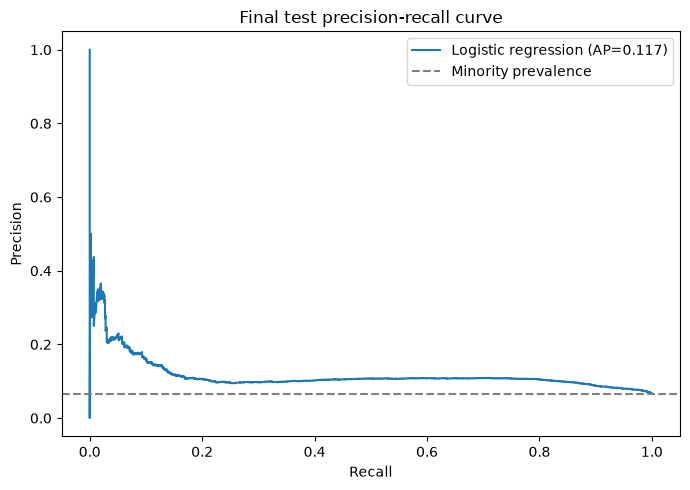

# Model results

- Baseline: prior-probability dummy classifier.
- Selected model: class-weighted logistic regression (`C=0.01`).
- Selection metric: validation average precision (appropriate for minority late deliveries).
- Baseline validation AP: **0.053**.
- Model validation AP: **0.150**.
- Final test AP: **0.117**.
- Final test ROC AUC: **0.677**; recall: **0.848**; F1: **0.176**.
- Test was used once, after model and hyperparameter selection.



In [5]:
# The model/hyperparameter choice is now frozen. Test is evaluated once below.
test_result = metrics_for(selected_model, X["test"], y["test"])
results = {
    "selection_metric": "average_precision",
    "best_C": best_c,
    "baseline_validation": baseline_validation,
    "selected_model_validation": selected_validation,
    "selected_model_test": test_result,
}
(OUT / "results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
joblib.dump(selected_model, OUT / "trained_model.joblib")

test_probability = selected_model.predict_proba(X["test"])[:, 1]
precision, recall, _ = precision_recall_curve(y["test"], test_probability)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label=f"Logistic regression (AP={test_result['average_precision']:.3f})")
ax.axhline(y["test"].mean(), color="gray", linestyle="--", label="Minority prevalence")
ax.set(xlabel="Recall", ylabel="Precision", title="Final test precision-recall curve")
ax.legend(); fig.tight_layout(); fig.savefig(OUT / "test_precision_recall_curve.png", dpi=140); plt.show()

summary = f'''# Model results

- Baseline: prior-probability dummy classifier.
- Selected model: class-weighted logistic regression (`C={best_c}`).
- Selection metric: validation average precision (appropriate for minority late deliveries).
- Baseline validation AP: **{baseline_validation['average_precision']:.3f}**.
- Model validation AP: **{selected_validation['average_precision']:.3f}**.
- Final test AP: **{test_result['average_precision']:.3f}**.
- Final test ROC AUC: **{test_result['roc_auc']:.3f}**; recall: **{test_result['recall']:.3f}**; F1: **{test_result['f1']:.3f}**.
- Test was used once, after model and hyperparameter selection.
'''
(OUT / "results_summary.md").write_text(summary, encoding="utf-8")
print(summary)